# DevOps AI Agent ” ML Pipeline Training & Evaluation

Research Notebook: Hybrid ML approach for autonomous DevOps observability analysis.

**Research Question:** Can an ensemble of specialised ML models match or exceed a large language model (Claude API) for real-time DevOps anomaly detection, forecasting, root cause analysis, and operational reporting?

**Models:**
1. Anomaly Detection â€” Isolation Forest + LSTM Autoencoder
2. Time-Series Forecasting â€” LSTM with Multi-head Attention
3. Root Cause Classification â€” XGBoost
4. Log Clustering â€” Sentence-BERT + UMAP + HDBSCAN
5. NLP Report Generation â€” Phi-3-mini (4-bit quantised)

In [3]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path

# Project paths
PROJECT_ROOT = Path(".").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from config import (
    DATA_DIR, MODEL_DIR, ARTIFACT_DIR, DEVICE,
    METRIC_FEATURES, ROOT_CAUSE_LABELS, SERVICES,
    anomaly_config, forecast_config, root_cause_config, log_cluster_config,
    training_config,
)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
print(f"Device: {DEVICE}")
print(f"Features: {METRIC_FEATURES}")
print(f"Services: {SERVICES}")

Device: cpu
Features: ['request_rate', 'error_rate', 'latency_p50', 'latency_p99', 'jvm_heap_used', 'jvm_gc_pause_seconds', 'cpu_usage', 'memory_usage']
Services: ['movie-service', 'actor-service', 'review-service']


## 1. Data Generation & Exploration

In [4]:
from data.generators.metric_generator import generate_training_dataset
from data.generators.log_generator import generate_log_dataset

# Generate training data
metrics_df, windows_df = generate_training_dataset(
    n_normal_windows=3000,
    n_anomaly_windows=1500,
    seed=42,
)
logs_df = generate_log_dataset(n_logs=20000, seed=42)

print(f"Metrics: {metrics_df.shape}")
print(f"Windows: {windows_df.shape}")
print(f"Logs: {logs_df.shape}")

[data] Generated 270000 metric samples in 4500 windows
[data] Label distribution:
label
normal                   3383
config_error              171
request_spike             168
memory_leak               166
cpu_saturation            160
deployment_regression     160
jvm_gc_pressure           149
downstream_timeout        143
[log_gen] Generated 20000 log entries
[log_gen] Severity distribution:
severity
INFO     12008
WARN      3960
ERROR     2986
FATAL     1046
[log_gen] Cluster distribution:
cluster_label
batch_processing       1749
db_query_success       1724
request_complete       1724
health_check           1723
api_request            1715
pool_stats             1712
cache_hit              1661
startup_failure        1046
retry_attempt           722
circuit_breaker         684
heap_warning            665
slow_query              661
slo_breach              643
pool_exhaustion         585
null_pointer            449
service_unavailable     448
ssl_error               429
db_pool_ex

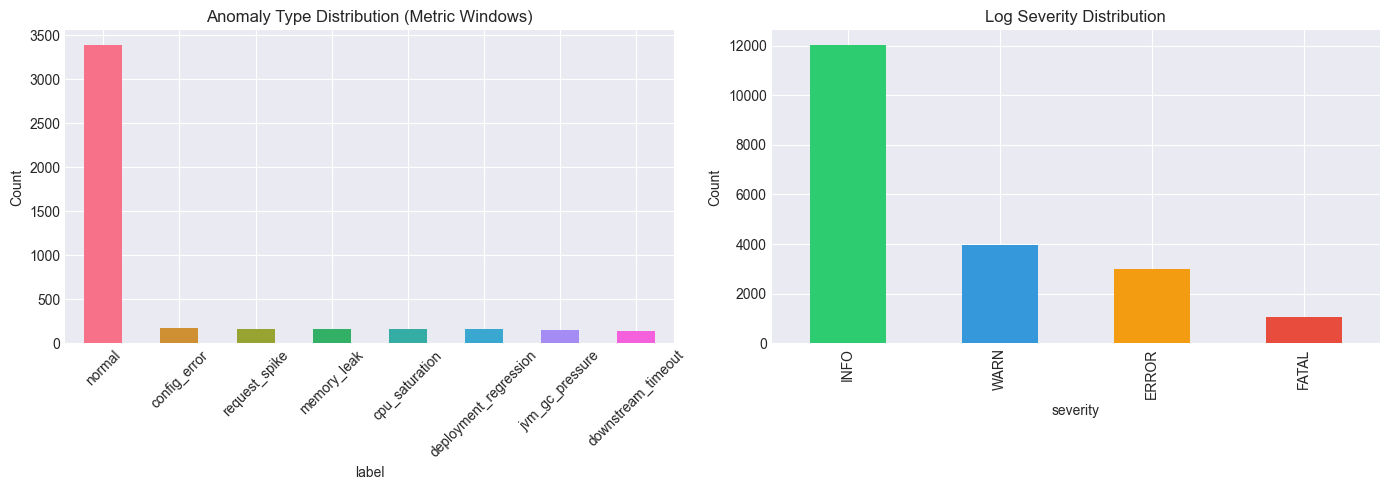

In [5]:
# Label distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

windows_df['label'].value_counts().plot.bar(ax=axes[0], color=sns.color_palette('husl', len(windows_df['label'].unique())))
axes[0].set_title('Anomaly Type Distribution (Metric Windows)')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

logs_df['severity'].value_counts().plot.bar(ax=axes[1], color=['#2ecc71', '#3498db', '#f39c12', '#e74c3c', '#8e44ad'])
axes[1].set_title('Log Severity Distribution')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig(str(ARTIFACT_DIR / 'data_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

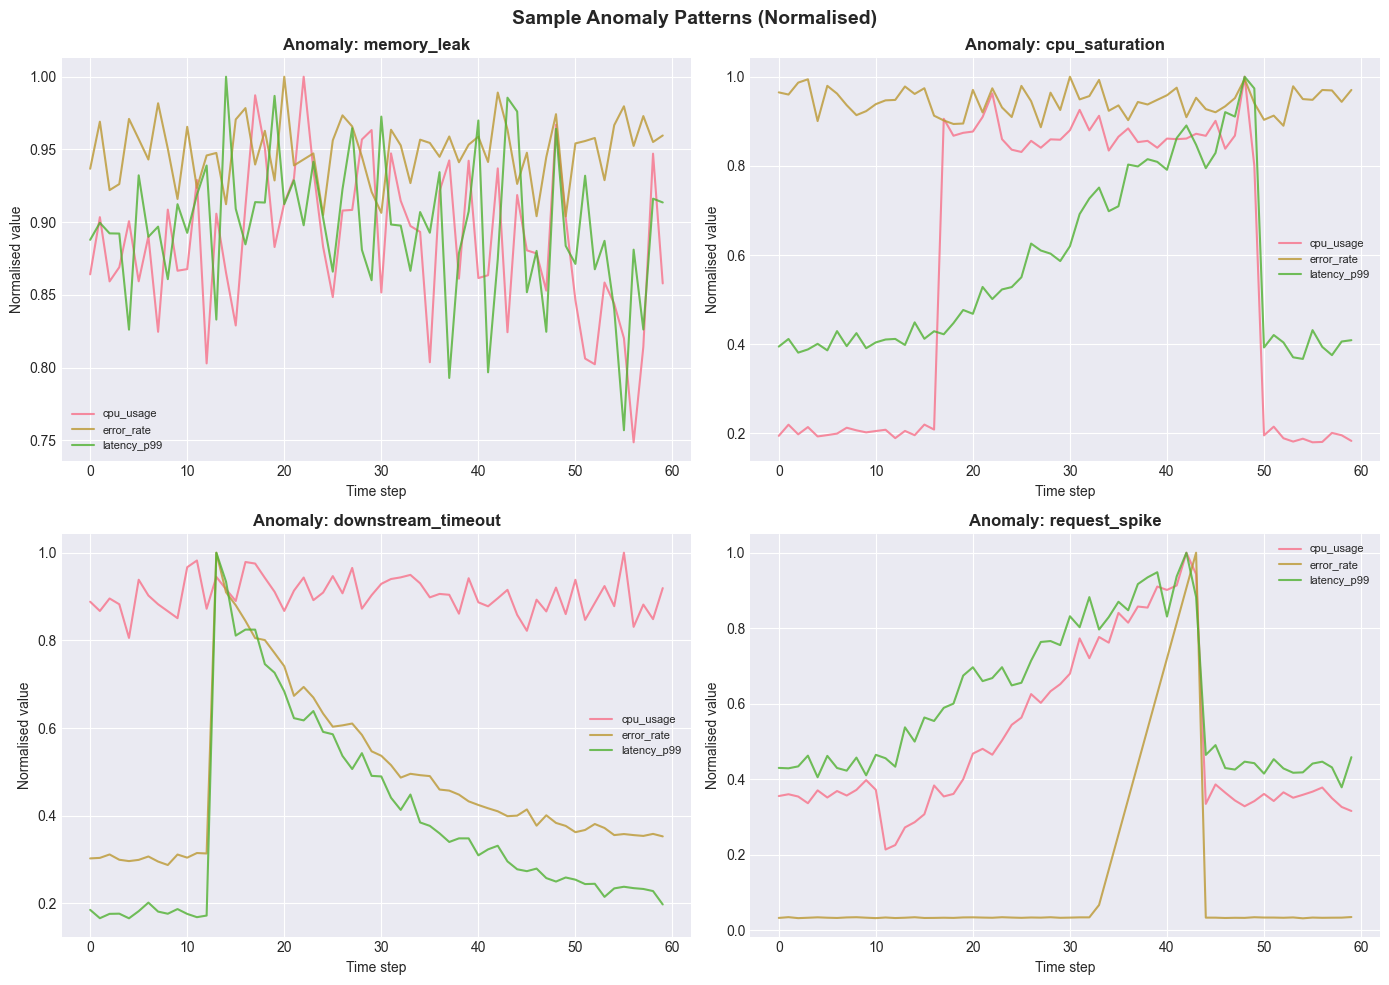

In [6]:
# Sample anomaly patterns visualisation
anomaly_types = ['memory_leak', 'cpu_saturation', 'downstream_timeout', 'request_spike']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, atype in zip(axes.flat, anomaly_types):
    window_id = windows_df[windows_df['label'] == atype]['window_id'].iloc[0]
    window = metrics_df[metrics_df['window_id'] == window_id]
    
    for feat in ['cpu_usage', 'error_rate', 'latency_p99']:
        vals = window[feat].values
        ax.plot(vals / vals.max() if vals.max() > 0 else vals, label=feat, alpha=0.8)
    
    ax.set_title(f'Anomaly: {atype}', fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_xlabel('Time step')
    ax.set_ylabel('Normalised value')

plt.suptitle('Sample Anomaly Patterns (Normalised)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(ARTIFACT_DIR / 'anomaly_patterns.png'), dpi=150, bbox_inches='tight')
plt.show()

## 2. Train/Val/Test Split

In [7]:
from sklearn.model_selection import train_test_split

window_ids = windows_df['window_id'].values
labels = windows_df['label'].values

train_ids, temp_ids = train_test_split(window_ids, test_size=0.30, stratify=labels, random_state=42)
temp_labels = windows_df[windows_df['window_id'].isin(temp_ids)]['label'].values
val_ids, test_ids = train_test_split(temp_ids, test_size=0.50, stratify=temp_labels, random_state=42)

splits = {
    'train': {'windows': windows_df[windows_df['window_id'].isin(train_ids)],
              'metrics': metrics_df[metrics_df['window_id'].isin(train_ids)]},
    'val':   {'windows': windows_df[windows_df['window_id'].isin(val_ids)],
              'metrics': metrics_df[metrics_df['window_id'].isin(val_ids)]},
    'test':  {'windows': windows_df[windows_df['window_id'].isin(test_ids)],
              'metrics': metrics_df[metrics_df['window_id'].isin(test_ids)]},
}

for name, data in splits.items():
    print(f"{name}: {len(data['windows'])} windows, {len(data['metrics'])} samples")
    print(f"  Labels: {data['windows']['label'].value_counts().to_dict()}")

train: 3150 windows, 189000 samples
  Labels: {'normal': 2368, 'config_error': 120, 'request_spike': 118, 'memory_leak': 116, 'cpu_saturation': 112, 'deployment_regression': 112, 'jvm_gc_pressure': 104, 'downstream_timeout': 100}
val: 675 windows, 40500 samples
  Labels: {'normal': 504, 'config_error': 31, 'cpu_saturation': 26, 'memory_leak': 24, 'deployment_regression': 23, 'request_spike': 23, 'downstream_timeout': 22, 'jvm_gc_pressure': 22}
test: 675 windows, 40500 samples
  Labels: {'normal': 511, 'request_spike': 27, 'memory_leak': 26, 'deployment_regression': 25, 'jvm_gc_pressure': 23, 'cpu_saturation': 22, 'downstream_timeout': 21, 'config_error': 20}


## 3. Model Training

### 3.1 Anomaly Detection (Isolation Forest + LSTM Autoencoder)

In [8]:
from models.anomaly.detector import AnomalyDetector

detector = AnomalyDetector()

# Train Isolation Forest
if_results = detector.train_isolation_forest(splits['train']['windows'])
print(f"\nIsolation Forest â€” P: {if_results['precision']:.3f}, R: {if_results['recall']:.3f}, F1: {if_results['f1']:.3f}")

# Train LSTM Autoencoder
lstm_results = detector.train_lstm_autoencoder(
    splits['train']['metrics'],
    splits['val']['metrics'],
)
print(f"LSTM-AE â€” P: {lstm_results['precision']:.3f}, R: {lstm_results['recall']:.3f}, F1: {lstm_results['f1']:.3f}, AUC: {lstm_results['auc']:.3f}")

detector.save()


[IF] Training Isolation Forest...
[IF] Train metrics — P: 0.994, R: 0.201, F1: 0.334

Isolation Forest â€” P: 0.994, R: 0.201, F1: 0.334

[LSTM-AE] Training LSTM Autoencoder...
[LSTM-AE] Training sequences: (150318, 30, 8)
[LSTM-AE] Epoch   0 — loss: 0.094261, val_loss: 0.734508
[LSTM-AE] Epoch  10 — loss: 0.068073, val_loss: 0.705178
[LSTM-AE] Epoch  20 — loss: 0.057053, val_loss: 0.687926
[LSTM-AE] Epoch  30 — loss: 0.047852, val_loss: 0.676019
[LSTM-AE] Epoch  40 — loss: 0.041765, val_loss: 0.676755
[LSTM-AE] Epoch  50 — loss: 0.039056, val_loss: 0.675580
[LSTM-AE] Epoch  60 — loss: 0.036778, val_loss: 0.676297
[LSTM-AE] Early stopping at epoch 61
[LSTM-AE] Reconstruction threshold: 0.069561
[LSTM-AE] Metrics — P: 0.883, R: 0.988, F1: 0.933, AUC: 0.986
LSTM-AE â€” P: 0.883, R: 0.988, F1: 0.933, AUC: 0.986
[anomaly] Models saved to d:\ResearchWithDrSatish\Alex\devops-agent\ml-models\trained_models\anomaly


### 3.2 Time-Series Forecasting (LSTM + Attention)

In [9]:
from models.forecasting.forecaster import MetricForecaster

forecaster = MetricForecaster()
forecast_results = forecaster.train(
    splits['train']['metrics'],
    splits['val']['metrics'],
)
forecaster.save()

print(f"\nForecaster Results:")
for k, v in forecast_results.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.4f}")


[forecast] Training LSTM Forecaster with Attention...


[forecast] Epoch   0 — train: 0.124039, val: 0.104988, lr: 5.00e-04
[forecast] Epoch  10 — train: 0.096108, val: 0.093965, lr: 5.00e-04
[forecast] Epoch  20 — train: 0.082116, val: 0.099019, lr: 2.50e-04
[forecast] Early stopping at epoch 27
[forecast] train — MAE: 1908850.2500, RMSE: 7405189.0877
[forecast] val — MAE: 1927992.1250, RMSE: 7514049.4824
[forecast] Model saved to d:\ResearchWithDrSatish\Alex\devops-agent\ml-models\trained_models\forecasting

Forecaster Results:
  train_mae: 1908850.2500
  train_rmse: 7405189.0877
  val_mae: 1927992.1250
  val_rmse: 7514049.4824


### 3.3 Root Cause Classification (XGBoost)


[root_cause] Training XGBoost Root Cause Classifier...
[root_cause] SMOTE: 782 → 840 samples
[root_cause] Train — Accuracy: 1.000, F1: 1.000
[root_cause] Top 10 features:
  jvm_gc_pause_seconds_roll30_mean: 0.2111
  memory_usage_std: 0.0400
  cpu_usage_mean: 0.0373
  jvm_gc_pause_seconds_acceleration: 0.0361
  request_rate_trend: 0.0360
  request_rate_max: 0.0355
  memory_usage_mean: 0.0330
  latency_p99_cv: 0.0295
  jvm_heap_used_range: 0.0289
  memory_usage_max: 0.0286


d:\ResearchWithDrSatish\Alex\devops-agent\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:57:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\ResearchWithDrSatish\Alex\devops-agent\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:57:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\ResearchWithDrSatish\Alex\devops-agent\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:57:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\ResearchWithDrSatish\Alex\devops-agent\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:57:37] WARNING: C:\actions-runner\_work\xgboost\xgbo

[root_cause] 5-fold CV — F1: 1.000 ± 0.000

[root_cause] Classification Report:
                       precision    recall  f1-score   support

         config_error       1.00      1.00      1.00       120
       cpu_saturation       1.00      1.00      1.00       112
deployment_regression       1.00      1.00      1.00       112
   downstream_timeout       1.00      1.00      1.00       100
      jvm_gc_pressure       1.00      1.00      1.00       104
          memory_leak       1.00      1.00      1.00       116
        request_spike       1.00      1.00      1.00       118

             accuracy                           1.00       782
            macro avg       1.00      1.00      1.00       782
         weighted avg       1.00      1.00      1.00       782

[root_cause] Model saved to d:\ResearchWithDrSatish\Alex\devops-agent\ml-models\trained_models\root_cause


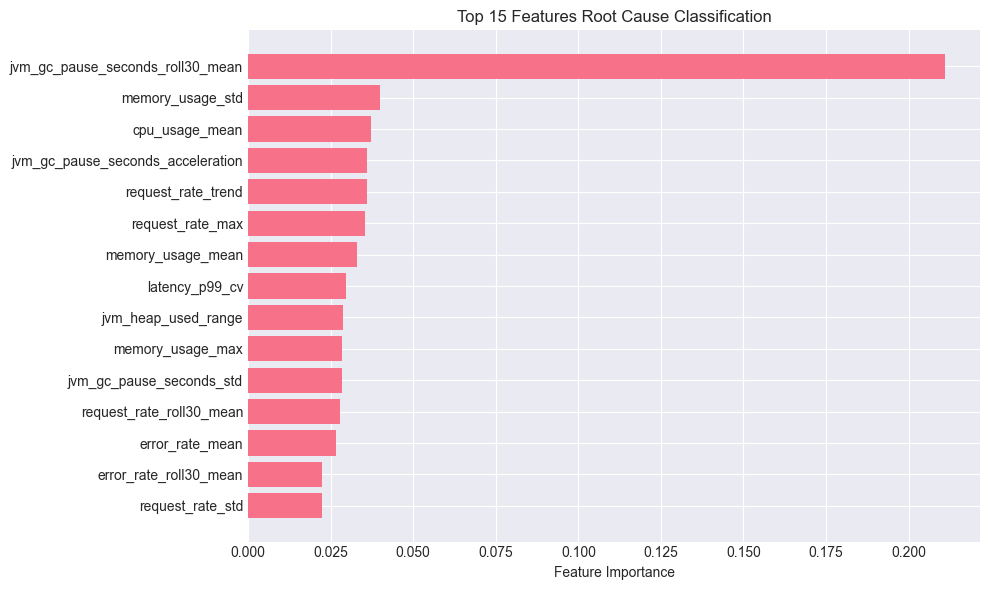

In [10]:
from models.root_cause.classifier import RootCauseClassifier

classifier = RootCauseClassifier()
rc_results = classifier.train(
    splits['train']['windows'],
    splits['train']['metrics'],
)
classifier.save()

# Feature importance plot
top_features = dict(list(classifier.feature_importance.items())[:15])
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(list(top_features.keys())[::-1], list(top_features.values())[::-1])
ax.set_xlabel('Feature Importance')
ax.set_title('Top 15 Features Root Cause Classification')
plt.tight_layout()
plt.savefig(str(ARTIFACT_DIR / 'feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

### 3.4 Log Clustering (Sentence-BERT + HDBSCAN)

In [11]:
from models.log_clustering.clusterer import LogClusterer

clusterer = LogClusterer()
cluster_results = clusterer.train(logs_df)
clusterer.save()

print(f"\nClustering Results:")
for k, v in cluster_results.items():
    if isinstance(v, (int, float)):
        print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

# Pattern summary
summary = clusterer.get_pattern_summary()
print(f"\nDiscovered {summary['total_patterns']} patterns")
for p in summary['patterns'][:5]:
    print(f"  Cluster {p['cluster_id']} ({p['size']} logs): {p['label']}")

d:\ResearchWithDrSatish\Alex\devops-agent\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



[log_cluster] Training Log Clustering Pipeline...
[log_cluster] Loading encoder: all-MiniLM-L6-v2...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8255.56it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[log_cluster] Encoder loaded (384d embeddings)
[log_cluster] Encoding 20000 messages...


Batches: 100%|██████████| 79/79 [00:31<00:00,  2.49it/s]
d:\ResearchWithDrSatish\Alex\devops-agent\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[log_cluster] Embeddings shape: (20000, 384)
[log_cluster] Fitting UMAP (384d → 15d)...
[log_cluster] UMAP reduced: (20000, 15)
[log_cluster] Fitting HDBSCAN...
[log_cluster] Found 1033 clusters, 2079 noise points (10.4%)
[log_cluster] Extracted patterns for 1033 clusters
[log_cluster] Silhouette score: 0.822
[log_cluster] ARI: 0.170, NMI: 0.633, V-measure: 0.633
[log_cluster] Models saved to d:\ResearchWithDrSatish\Alex\devops-agent\ml-models\trained_models\log_clustering

Clustering Results:
  n_clusters: 1033
  n_noise_points: 2079
  silhouette_score: 0.8215
  adjusted_rand_index: 0.1704
  normalised_mutual_info: 0.6334
  homogeneity: 1.0000
  completeness: 0.4635
  v_measure: 0.6334

Discovered 1033 patterns
  Cluster 0 (13 logs): FATAL: Application startup failed:
  Cluster 1 (55 logs): FATAL: Application startup failed:
  Cluster 2 (10 logs): FATAL: Application startup failed:
  Cluster 3 (9 logs): FATAL: Application startup failed:
  Cluster 4 (10 logs): INFO: Processing batch o

## 4. Test Set Evaluation

In [12]:
from evaluation.benchmark import ModelEvaluator

evaluator = ModelEvaluator()

#  Anomaly Detection on test set 
test_windows = splits['test']['windows']
test_metrics = splits['test']['metrics']

y_true, y_pred, y_scores = [], [], []
for wid in test_windows['window_id'].unique():
    window = test_metrics[test_metrics['window_id'] == wid]
    if len(window) >= 30:
        result = detector.predict(window)
        y_true.append(int(test_windows[test_windows['window_id'] == wid]['is_anomaly'].iloc[0]))
        y_pred.append(int(result['is_anomaly']))
        y_scores.append(result['anomaly_score'])

anomaly_eval = evaluator.evaluate_anomaly_detector(
    np.array(y_true), np.array(y_pred), np.array(y_scores)
)
print("Anomaly Detection (Test Set):")
for k, v in anomaly_eval.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

Anomaly Detection (Test Set):
  precision: 0.7225
  recall: 1.0000
  f1_score: 0.8389
  auc_roc: 0.9687
  true_positives: 164
  false_positives: 63
  true_negatives: 448
  false_negatives: 0
  false_positive_rate: 0.1233
  miss_rate: 0.0000


Root Cause Classification (Test Set):
                       precision    recall  f1-score   support

         config_error       1.00      1.00      1.00        20
       cpu_saturation       1.00      1.00      1.00        22
deployment_regression       1.00      1.00      1.00        25
   downstream_timeout       1.00      1.00      1.00        21
      jvm_gc_pressure       1.00      1.00      1.00        23
          memory_leak       1.00      1.00      1.00        26
        request_spike       1.00      1.00      1.00        27

             accuracy                           1.00       164
            macro avg       1.00      1.00      1.00       164
         weighted avg       1.00      1.00      1.00       164



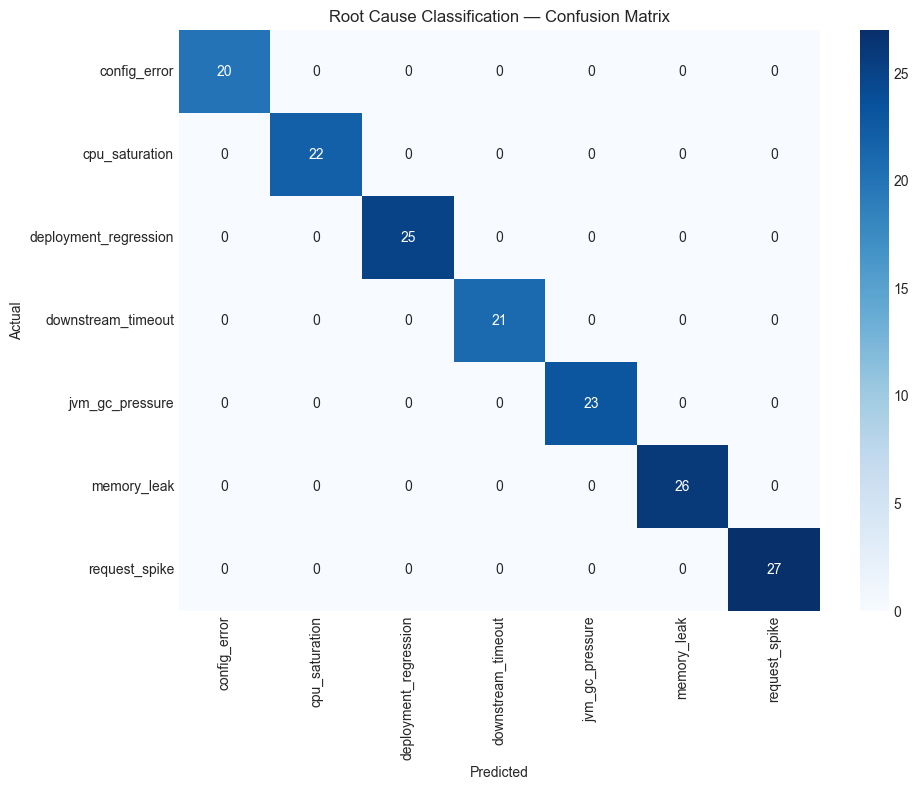

In [13]:
# ── Root Cause Classification on test set ──
from models.root_cause.classifier import RootCauseClassifier
import models.root_cause.classifier

# Auto-load classifier from disk if training cell was skipped
if "classifier" not in globals():
    print("[notebook] Loading classifier from disk...")
    classifier = RootCauseClassifier()
    classifier.load()

# Extract test split if cell-17 was skipped
if "test_windows" not in globals():
    test_windows = splits["test"]["windows"]
    test_metrics = splits["test"]["metrics"]

anomaly_test = test_windows[test_windows["label"] != "normal"]
rc_true, rc_pred, rc_conf = [], [], []

for _, row in anomaly_test.iterrows():
    window = test_metrics[test_metrics["window_id"] == row["window_id"]]
    if len(window) > 0:
        pred = classifier.predict(window)
        rc_true.append(row["label"])
        rc_pred.append(pred["predicted_cause"])
        rc_conf.append(pred["confidence"])

from sklearn.metrics import classification_report, confusion_matrix
print("Root Cause Classification (Test Set):")
print(classification_report(rc_true, rc_pred))

# Confusion matrix
unique_labels = sorted(set(rc_true + rc_pred))
cm = confusion_matrix(rc_true, rc_pred, labels=unique_labels)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=unique_labels, yticklabels=unique_labels, cmap="Blues", ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Root Cause Classification — Confusion Matrix")
plt.tight_layout()
plt.savefig(str(ARTIFACT_DIR / "confusion_matrix.png"), dpi=150, bbox_inches="tight")
plt.show()

## 5. Latency Benchmarking

In [14]:
from evaluation.benchmark import LatencyBenchmark

bench = LatencyBenchmark()

# Prepare a sample window
sample_wid = test_windows['window_id'].iloc[0]
sample_window = test_metrics[test_metrics['window_id'] == sample_wid]

# Benchmark each model
latency_results = {}
latency_results['anomaly_detection'] = bench.measure(detector.predict, sample_window, n_runs=50)
latency_results['forecasting'] = bench.measure(forecaster.predict, sample_window, n_runs=50)
latency_results['root_cause'] = bench.measure(classifier.predict, sample_window, n_runs=50)

print("\nLatency Benchmark Results:")
print(f"{'Model':<25} {'Mean (ms)':<12} {'P95 (ms)':<12} {'P99 (ms)':<12}")
print("-" * 60)
for name, res in latency_results.items():
    print(f"{name:<25} {res['mean_ms']:<12.2f} {res['p95_ms']:<12.2f} {res['p99_ms']:<12.2f}")


Latency Benchmark Results:
Model                     Mean (ms)    P95 (ms)     P99 (ms)    
------------------------------------------------------------
anomaly_detection         21.39        23.47        25.28       
forecasting               37.21        43.25        45.78       
root_cause                7.23         8.72         10.10       


## 6. Cost Analysis  ML vs Claude API

In [15]:
from evaluation.benchmark import CostAnalyser

cost = CostAnalyser()
comparison = cost.compare(
    avg_input_tokens=2000,
    avg_output_tokens=800,
    calls_per_day=288,  # every 5 minutes
)

print("\nCost Comparison (Monthly):")
print(f"  Claude API:  ${comparison['api_cost']['monthly_total_cost_usd']:.2f}/month")
print(f"  ML Pipeline: ${comparison['ml_cost']['monthly_cost_usd']:.2f}/month")
print(f"  Savings:     ${comparison['monthly_savings_usd']:.2f}/month ({comparison['savings_percentage']:.1f}%)")
print(f"\n  GPU utilisation: {comparison['ml_cost']['gpu_utilisation_pct']:.2f}%")


Cost Comparison (Monthly):
  Claude API:  $155.52/month
  ML Pipeline: $3.84/month
  Savings:     $151.68/month (97.5%)

  GPU utilisation: 1.07%


## 7. Statistical Significance Testing

In [16]:
from evaluation.benchmark import StatisticalTests

tests = StatisticalTests()

# Bootstrap CI for anomaly detection F1
# (In practice, collect per-sample scores from multiple runs)
anomaly_scores = np.array(y_scores)
ci = tests.bootstrap_ci(anomaly_scores, n_bootstrap=10000, confidence=0.95)
print(f"\nAnomaly Score 95% CI: [{ci['ci_lower']:.4f}, {ci['ci_upper']:.4f}]")
print(f"Mean: {ci['mean']:.4f} Â± {ci['std']:.4f}")


Anomaly Score 95% CI: [0.4199, 0.4568]
Mean: 0.4381 Â± 0.2430


## 8. Results Summary Table (Publication-Ready)

In [17]:
# Compile all results into a summary table
results_table = pd.DataFrame([
    {'Model': 'Anomaly Detection (IF+LSTM)', 
     'Precision': anomaly_eval.get('precision', 0),
     'Recall': anomaly_eval.get('recall', 0),
     'F1': anomaly_eval.get('f1_score', 0),
     'AUC-ROC': anomaly_eval.get('auc_roc', 0),
     'Latency (ms)': latency_results.get('anomaly_detection', {}).get('mean_ms', 0),
    },
    {'Model': 'Forecaster (LSTM+Attn)',
     'MAE': forecast_results.get('train_mae', 0),
     'RMSE': forecast_results.get('train_rmse', 0),
     'Latency (ms)': latency_results.get('forecasting', {}).get('mean_ms', 0),
    },
    {'Model': 'Root Cause (XGBoost)',
     'Accuracy': rc_results.get('train_accuracy', 0),
     'F1 (weighted)': rc_results.get('train_f1_weighted', 0),
     'CV F1': rc_results.get('cv_f1_mean', 0),
     'Latency (ms)': latency_results.get('root_cause', {}).get('mean_ms', 0),
    },
    {'Model': 'Log Clustering (SBERT+HDBSCAN)',
     'Silhouette': cluster_results.get('silhouette_score', 0),
     'ARI': cluster_results.get('adjusted_rand_index', 0),
     'NMI': cluster_results.get('normalised_mutual_info', 0),
     'Clusters': cluster_results.get('n_clusters', 0),
    },
])

print("\n" + "=" * 70)
print("  RESULTS SUMMARY")
print("=" * 70)
print(results_table.to_string(index=False))

# Save
results_table.to_csv(str(ARTIFACT_DIR / 'results_summary.csv'), index=False)
print(f"\nSaved to {ARTIFACT_DIR / 'results_summary.csv'}")


  RESULTS SUMMARY
                         Model  Precision  Recall       F1  AUC-ROC  Latency (ms)        MAE         RMSE  Accuracy  F1 (weighted)  CV F1  Silhouette      ARI      NMI  Clusters
   Anomaly Detection (IF+LSTM)   0.722467     1.0 0.838875 0.968689     21.390342        NaN          NaN       NaN            NaN    NaN         NaN      NaN      NaN       NaN
        Forecaster (LSTM+Attn)        NaN     NaN      NaN      NaN     37.213680 1908850.25 7.405189e+06       NaN            NaN    NaN         NaN      NaN      NaN       NaN
          Root Cause (XGBoost)        NaN     NaN      NaN      NaN      7.228794        NaN          NaN       1.0            1.0    1.0         NaN      NaN      NaN       NaN
Log Clustering (SBERT+HDBSCAN)        NaN     NaN      NaN      NaN           NaN        NaN          NaN       NaN            NaN    NaN    0.821545 0.170366 0.633378    1033.0

Saved to d:\ResearchWithDrSatish\Alex\devops-agent\ml-models\artifacts\results_summary.csv

In [18]:
# Save all results as JSON artifact for reproducibility
all_results = {
    'anomaly_detection': {
        'isolation_forest': if_results,
        'lstm_autoencoder': lstm_results,
        'test_evaluation': anomaly_eval,
        'latency': latency_results.get('anomaly_detection', {}),
    },
    'forecasting': {
        'training': forecast_results,
        'latency': latency_results.get('forecasting', {}),
    },
    'root_cause': {
        'training': rc_results,
        'latency': latency_results.get('root_cause', {}),
    },
    'log_clustering': cluster_results,
    'cost_analysis': comparison,
}

with open(ARTIFACT_DIR / 'full_results.json', 'w') as f:
    json.dump(all_results, f, indent=2, default=str)

print(f"Full results saved to {ARTIFACT_DIR / 'full_results.json'}")

Full results saved to d:\ResearchWithDrSatish\Alex\devops-agent\ml-models\artifacts\full_results.json
